In [ ]:
pip install numpy pillow matplotlib scipy pandas


  Bit Dot Night — Quantitative Aesthetic Analysis
Processed: AND  (x & y)
Processed: OR   (x | y)
Processed: XOR  (x ^ y)
Processed: ADD  (x + y)
Processed: MULTIPLY (x * y)
Processed: HYBRID (x−y)⊕(x+y)


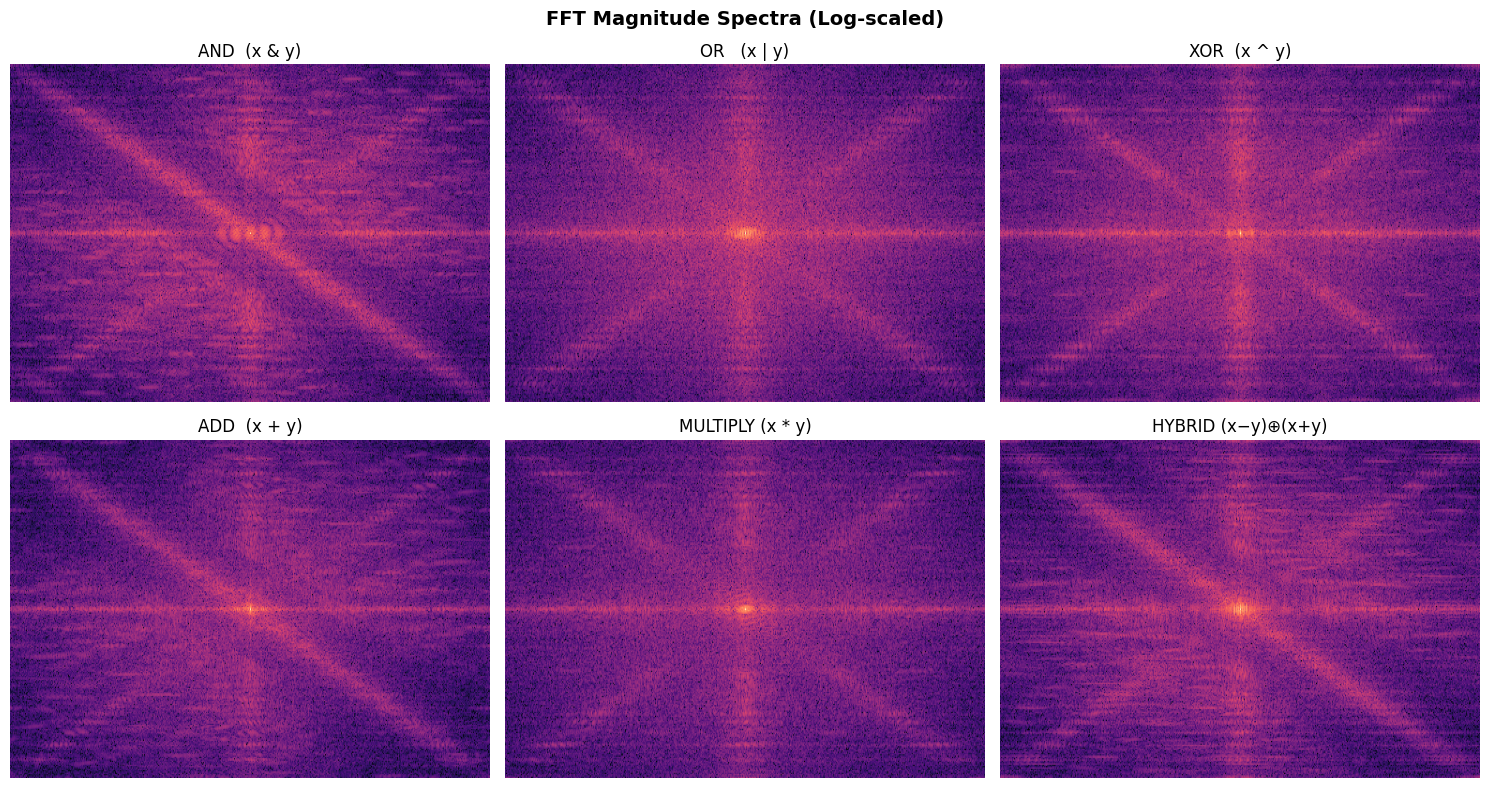

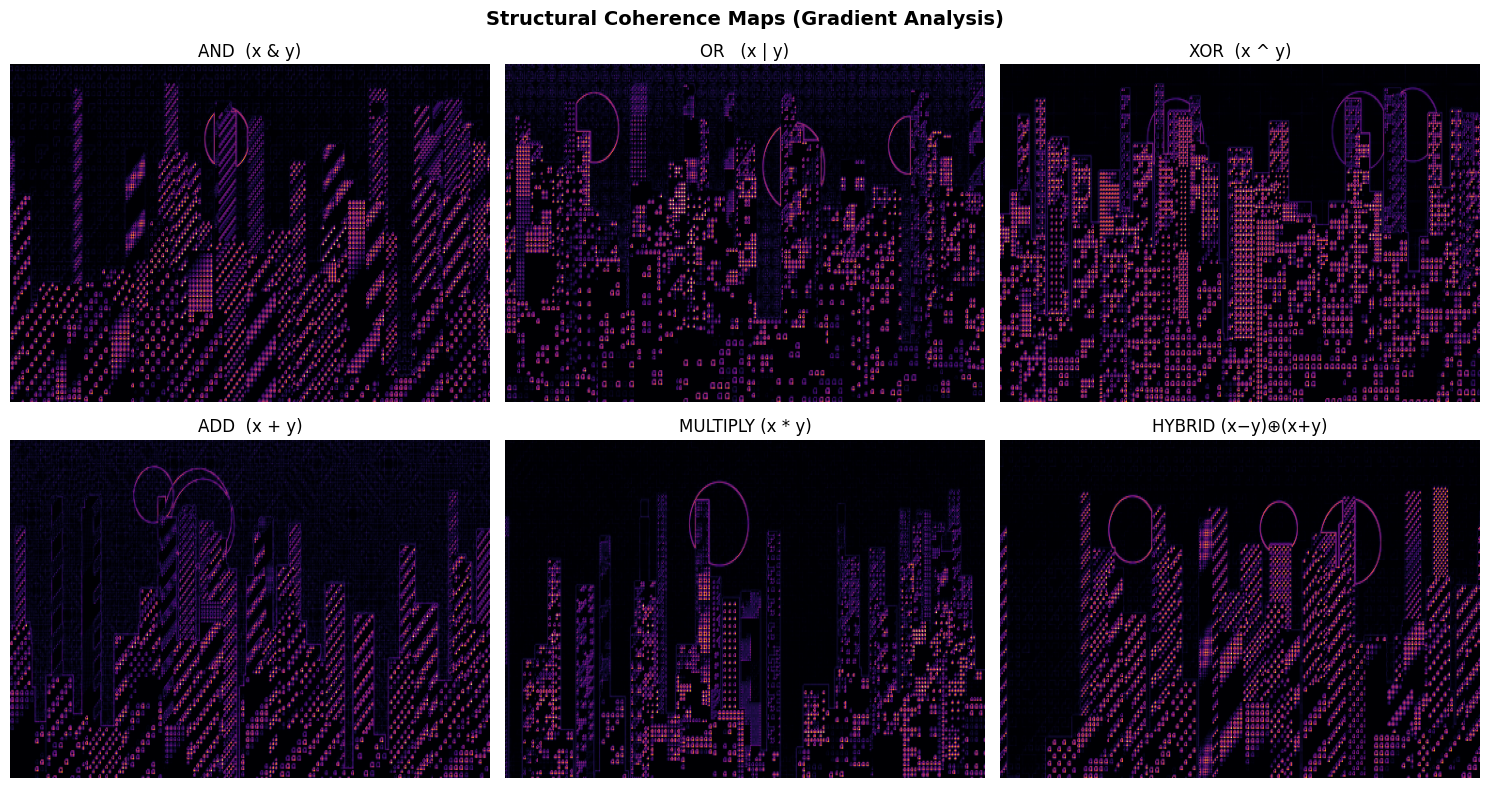


  PAPER TABLE — paste into LaTeX
Operator                     σ²    Low%    Mid%   High%         C
-----------------------------------------------------------------
AND  (x & y)            0.02645    37.6    19.0    43.4   0.06571
OR   (x | y)            0.04059    57.8    17.8    24.4   0.06304
XOR  (x ^ y)            0.05103    53.5    15.9    30.6   0.08984
ADD  (x + y)            0.03121    73.3    10.5    16.2   0.06123
MULTIPLY (x * y)        0.02552    71.0     8.5    20.5   0.04777
HYBRID (x−y)⊕(x+y)      0.04383    65.3    11.1    23.6   0.05958

 CSV saved as 'analysis_results.csv'


In [ ]:
# Bit Dot Night - Quantitative Aesthetic Analysis

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

OPERATORS = ["and", "or", "xor", "add", "multiply", "hybrid"]

OPERATOR_LABELS = {
    "and":      "AND  (x & y)",
    "or":       "OR   (x | y)",
    "xor":      "XOR  (x ^ y)",
    "add":      "ADD  (x + y)",
    "multiply": "MULTIPLY (x * y)",
    "hybrid":   "HYBRID (x−y)⊕(x+y)",
}

LOW_BAND  = (0.00, 0.15)
MID_BAND  = (0.15, 0.40)
HIGH_BAND = (0.40, 1.00)

OUTPUT_DIR = os.getcwd()

def load_as_lightness(path: str) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    img = img.resize((512, 256), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    L = 0.2126 * arr[:, :, 0] + 0.7152 * arr[:, :, 1] + 0.0722 * arr[:, :, 2]
    return L

def brightness_variance(L: np.ndarray) -> float:
    return float(np.var(L))

def spectral_energy_bands(L: np.ndarray):
    F = fftshift(fft2(L))
    magnitude = np.abs(F) ** 2

    h, w = L.shape
    cy, cx = h // 2, w // 2

    ys = np.arange(h) - cy
    xs = np.arange(w) - cx
    XX, YY = np.meshgrid(xs, ys)
    R = np.sqrt((XX / cx) ** 2 + (YY / cy) ** 2)

    E_low  = float(magnitude[R <= LOW_BAND[1]].sum())
    E_mid  = float(magnitude[(R > MID_BAND[0])  & (R <= MID_BAND[1])].sum())
    E_high = float(magnitude[R > HIGH_BAND[0]].sum())
    E_total = E_low + E_mid + E_high

    low_pct  = 100 * E_low  / E_total if E_total > 0 else 0
    mid_pct  = 100 * E_mid  / E_total if E_total > 0 else 0
    high_pct = 100 * E_high / E_total if E_total > 0 else 0

    return low_pct, mid_pct, high_pct, magnitude

def structural_coherence(L: np.ndarray) -> float:
    diff_h = np.abs(L[:, :-1] - L[:, 1:])
    diff_v = np.abs(L[:-1, :] - L[1:, :])
    h = min(diff_h.shape[0], diff_v.shape[0])
    w = min(diff_h.shape[1], diff_v.shape[1])
    C = float((diff_h[:h, :w].mean() + diff_v[:h, :w].mean()) / 2)
    return C

def analyze_all():
    records = []
    fft_data = {}
    lightness_maps = {}

    print("\n" + "="*65)
    print("  Bit Dot Night — Quantitative Aesthetic Analysis")
    print("="*65)

    for op in OPERATORS:
        path = os.path.join(OUTPUT_DIR, f"{op}.png")

        if not os.path.exists(path):
            print(f"✖ Missing: {op}.png (Skipping...)")
            continue

        L = load_as_lightness(path)
        lightness_maps[op] = L

        variance = brightness_variance(L)
        lp, mp, hp, mag = spectral_energy_bands(L)
        coherence = structural_coherence(L)

        fft_data[op] = mag

        records.append({
            "Operator":      OPERATOR_LABELS[op],
            "Variance σ²":   round(variance, 5),
            "E_low (%)":     round(lp, 1),
            "E_mid (%)":     round(mp, 1),
            "E_high (%)":    round(hp, 1),
            "Coherence C":   round(coherence, 5),
        })

        print(f"Processed: {OPERATOR_LABELS[op]}")

    if not records:
        print("Error: No images were processed. Check your filenames!")
        return

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("FFT Magnitude Spectra (Log-scaled)", fontsize=14, fontweight="bold")
    for ax, op in zip(axes.flat, OPERATORS):
        if op in fft_data:
            ax.imshow(np.log1p(fft_data[op]), cmap="magma", aspect="auto")
            ax.set_title(OPERATOR_LABELS[op])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Structural Coherence Maps (Gradient Analysis)", fontsize=14, fontweight="bold")
    for ax, op in zip(axes.flat, OPERATORS):
        if op in lightness_maps:
            L = lightness_maps[op]
            diff_h = np.abs(L[:, :-1] - L[:, 1:])
            diff_v = np.abs(L[:-1, :] - L[1:, :])
            h, w = min(diff_h.shape[0], diff_v.shape[0]), min(diff_h.shape[1], diff_v.shape[1])
            coh_map = (diff_h[:h, :w] + diff_v[:h, :w]) / 2
            ax.imshow(coh_map, cmap="inferno", aspect="auto")
            ax.set_title(OPERATOR_LABELS[op])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    print("\n" + "="*65)
    print("  PAPER TABLE — paste into LaTeX")
    print("="*65)
    print(f"{'Operator':<22} {'σ²':>8} {'Low%':>7} {'Mid%':>7} {'High%':>7} {'C':>9}")
    print("-"*65)
    for r in records:
        print(f"{r['Operator']:<22} {r['Variance σ²']:>8} {r['E_low (%)']:>7} "
              f"{r['E_mid (%)']:>7} {r['E_high (%)']:>7} {r['Coherence C']:>9}")
    print("="*65)

    pd.DataFrame(records).to_csv("analysis_results.csv", index=False)
    print("\n✓ CSV saved as 'analysis_results.csv'")

if __name__ == "__main__":
    analyze_all()